# 🔧 Notebook 02 — Preprocessing & Feature Engineering
**Projet :** Cervical Cancer Risk Prediction  
**Auteure :** Hadil Dhaya · 4th Year Data Science · Group 5

---
**Objectifs :**
- Nettoyer le dataset (NaN, doublons)
- Imputation KNN
- Feature Engineering (nouvelles features médicalement pertinentes)
- SMOTE pour rééquilibrage
- Normalisation StandardScaler
- Sauvegarder tous les artefacts dans `outputs/`

In [4]:
import pandas as pd
import numpy as np  # pyright: ignore[reportUnusedImport]
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
os.makedirs('../outputs', exist_ok=True)
print('✅ Imports OK')

✅ Imports OK


## 1. Chargement

In [5]:
df = pd.read_csv('../data/risk_factors_cervical_cancer.csv', na_values='?')
print(f'Shape original : {df.shape}')
df.head(3)

Shape original : (858, 36)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


## 2. Suppression colonnes > 80% NaN

In [6]:
seuil = 0.80
cols_drop = df.columns[df.isnull().mean() > seuil].tolist()
df = df.drop(columns=cols_drop)
print(f'Colonnes supprimées ({len(cols_drop)}) : {cols_drop}')
print(f'Shape après suppression : {df.shape}')

Colonnes supprimées (2) : ['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']
Shape après suppression : (858, 34)


## 3. Suppression des doublons

In [7]:
n_dup = df.duplicated().sum()
print(f'Doublons : {n_dup}')
if n_dup > 0:
    df = df.drop_duplicates()
    print(f'Supprimés → Shape : {df.shape}')
else:
    print('✅ Aucun doublon')

Doublons : 23
Supprimés → Shape : (835, 34)


## 4. Imputation KNN

In [8]:
y = df['Biopsy'].copy()
X = df.drop('Biopsy', axis=1)

print(f'NaN restants avant imputation : {X.isnull().sum().sum()}')

imputer = KNNImputer(n_neighbors=5)
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f'NaN après imputation          : {X_imp.isnull().sum().sum()}')
print('✅ Imputation KNN terminée')

NaN restants avant imputation : 1957
NaN après imputation          : 0
✅ Imputation KNN terminée


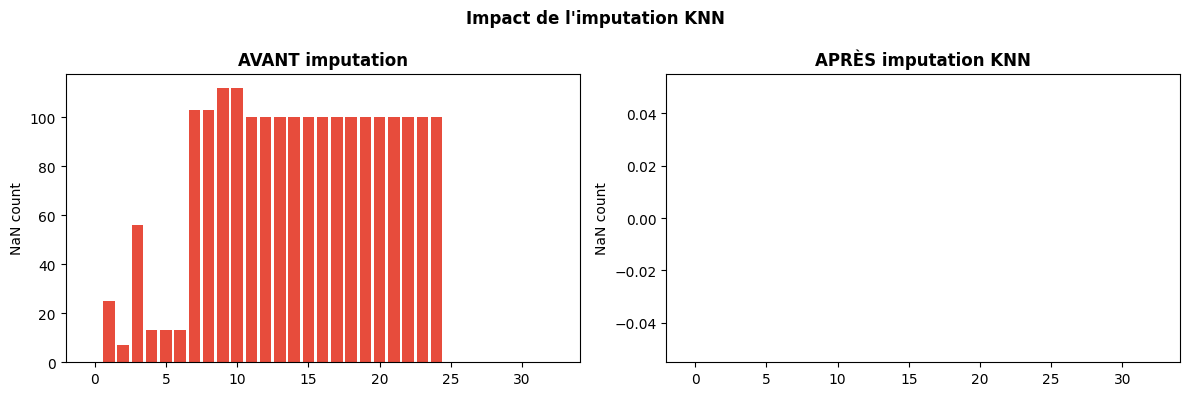

In [9]:
# Visualisation avant / après
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(X.shape[1]), X.isnull().sum(), color='#e74c3c')
axes[0].set_title('AVANT imputation', fontweight='bold')
axes[0].set_ylabel('NaN count')
axes[1].bar(range(X_imp.shape[1]), X_imp.isnull().sum(), color='#2ecc71')
axes[1].set_title('APRÈS imputation KNN', fontweight='bold')
axes[1].set_ylabel('NaN count')
plt.suptitle('Impact de l\'imputation KNN', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/imputation_result.png', dpi=150)
plt.show()

## 5. Feature Engineering

In [20]:
X_eng = X_imp.copy()

# Feature 1 : écart d'âge au 1er rapport (risque si très jeune)
if 'Age' in X_eng.columns and 'First sexual intercourse' in X_eng.columns:
    X_eng['age_first_sex_gap'] = X_eng['Age'] - X_eng['First sexual intercourse']
    print('✅ age_first_sex_gap créée')

# Feature 2 : exposition totale à la fumée (paquet × années)
if 'Smokes' in X_eng.columns and 'Smokes (years)' in X_eng.columns:
    packs = X_eng['Smokes (packs/year)'] if 'Smokes (packs/year)' in X_eng.columns else 1
    X_eng['smoke_exposure'] = X_eng['Smokes'] * X_eng['Smokes (years)'] * packs
    print('✅ smoke_exposure créée')

# Feature 3 : score IST cumulé
# Feature 3 : score IST simple (MATCH dashboard)
if 'STDs (number)' in X_eng.columns:
    X_eng['stds_score'] = X_eng['STDs (number)']
    print('✅ stds_score créée (copie de STDs (number))')

print(f'\nShape après feature engineering : {X_eng.shape}')

✅ age_first_sex_gap créée
✅ smoke_exposure créée
✅ stds_score créée (copie de STDs (number))

Shape après feature engineering : (835, 36)


In [21]:
X_eng = X_eng.drop(columns=[
    "STDs: Time since first diagnosis",
    "STDs: Time since last diagnosis"
], errors="ignore")

In [22]:
cols_to_remove = [
    'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx',
    'Hinselmann', 'Schiller', 'Citology'
]

X_eng = X_eng.drop(columns=cols_to_remove, errors='ignore')

In [23]:
X_eng = X_imp.copy()

# your features
X_eng['age_first_sex_gap'] = X_eng['Age'] - X_eng['First sexual intercourse']
X_eng['smoke_exposure'] = X_eng['Smokes'] * X_eng['Smokes (years)'] * X_eng['Smokes (packs/year)']
X_eng['stds_score'] = X_eng['STDs (number)']

## 6. Train / Test Split (stratifié)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_eng, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train : {X_train.shape}  |  y_train : {dict(y_train.value_counts())}')
print(f'X_test  : {X_test.shape}   |  y_test  : {dict(y_test.value_counts())}')

X_train : (668, 36)  |  y_train : {0: np.int64(625), 1: np.int64(43)}
X_test  : (167, 36)   |  y_test  : {0: np.int64(156), 1: np.int64(11)}


In [25]:
# ✅ IMPORTS
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# (example model — use yours)
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()

# ✅ SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_eng, y, test_size=0.2, random_state=42
)

# ✅ PIPELINE
pipeline = Pipeline([
    ("model", model)
])

# ✅ FIT
pipeline.fit(X_train, y_train)

# ✅ CHECK FEATURES
# Le Pipeline n'est pas encore défini ici — afficher les colonnes après le split
print(np.array(X_train.columns))

['Age' 'Number of sexual partners' 'First sexual intercourse'
 'Num of pregnancies' 'Smokes' 'Smokes (years)' 'Smokes (packs/year)'
 'Hormonal Contraceptives' 'Hormonal Contraceptives (years)' 'IUD'
 'IUD (years)' 'STDs' 'STDs (number)' 'STDs:condylomatosis'
 'STDs:cervical condylomatosis' 'STDs:vaginal condylomatosis'
 'STDs:vulvo-perineal condylomatosis' 'STDs:syphilis'
 'STDs:pelvic inflammatory disease' 'STDs:genital herpes'
 'STDs:molluscum contagiosum' 'STDs:AIDS' 'STDs:HIV' 'STDs:Hepatitis B'
 'STDs:HPV' 'STDs: Number of diagnosis' 'Dx:Cancer' 'Dx:CIN' 'Dx:HPV' 'Dx'
 'Hinselmann' 'Schiller' 'Citology' 'age_first_sex_gap' 'smoke_exposure'
 'stds_score']


## 7. SMOTE (uniquement sur train !)

In [19]:
print('AVANT SMOTE :', dict(y_train.value_counts()))
sm = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print('APRÈS SMOTE :', dict(pd.Series(y_train_res).value_counts()))
print(f'\n✅ Shape train après SMOTE : {X_train_res.shape}')

AVANT SMOTE : {0: np.int64(624), 1: np.int64(44)}
APRÈS SMOTE : {0: np.int64(624), 1: np.int64(624)}

✅ Shape train après SMOTE : (1248, 36)


In [10]:
print(pipeline.feature_names_in_)

NameError: name 'pipeline' is not defined

## 8. Normalisation StandardScaler

In [ ]:
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train_res), columns=X_train_res.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),          columns=X_test.columns)

print(f'Mean train ≈ {X_train_sc.mean().mean():.4f}  (doit être ≈ 0)')
print(f'Std  train ≈ {X_train_sc.std().mean():.4f}   (doit être ≈ 1)')
print('✅ Normalisation OK')

## 9. Sauvegarde des artefacts

In [ ]:
X_train_sc.to_csv('../outputs/X_train.csv', index=False)
X_test_sc.to_csv('../outputs/X_test.csv',  index=False)
pd.Series(y_train_res, name='Biopsy').to_csv('../outputs/y_train.csv', index=False)
y_test.reset_index(drop=True).to_csv('../outputs/y_test.csv', index=False)

joblib.dump(scaler,  '../outputs/scaler.pkl')
joblib.dump(imputer, '../outputs/imputer.pkl')

# Sauvegarder la liste des features pour le dashboard
import json
with open('../outputs/feature_names.json', 'w') as f:
    json.dump(X_eng.columns.tolist(), f)

print('✅ Fichiers sauvegardés dans outputs/')
for fname in os.listdir('../outputs/'):
    print(f'  → {fname}')
print('\n✅ Preprocessing terminé → lancer 03_Experiments.ipynb')